# Exploratory Data Analysis - dephi-100k Dataset

## Importing Libraries and Configuring the Notebook

This cell prepares the Python environment for the analysis. It imports the main libraries used for data processing, numerical calculations, visualisation, and text analysis.

The parent project directory is added to Python’s search path so that custom functions from the local `src` folder can be imported. These functions are used later to access tables stored in the OMOP database.

The pandas display settings are also adjusted to show up to 50 columns and format decimal values to two decimal places. A fixed colour palette is defined to keep the visualisations consistent throughout the notebook.

No data are loaded, modified, or removed in this cell.


In [1]:
# Add the parent project directory to Python's import path
import sys
sys.path.insert(0, "..")

# Data processing and numerical calculations
import pandas as pd
import numpy as np

# Data visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

# Text processing
import textwrap
import re

# Warning management
import warnings
warnings.filterwarnings("ignore")

# Custom functions for accessing OMOP database tables
from src.data_access.connection import get_table, list_omop_tables

# Configure pandas display settings
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.2f}".format)

# Define a consistent colour palette for visualisations
PALETTE = [
    "#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2",
    "#937860", "#DA8BC3", "#8C8C8C", "#CCB974", "#64B5CD"
]

## Overview of OMOP Database Tables

This cell retrieves the names of all available OMOP tables and counts the number of records stored in each table. The results are organised into a summary table and sorted from the largest table to the smallest.

A horizontal bar chart is created using only non-empty tables, making it easier to identify which clinical domains contain the most data. Empty tables remain in the full summary and are excluded only from the visualisation.

The total number of available tables and the number of non-empty tables are also printed. This provides an initial overview of the dataset structure before individual clinical tables are examined in more detail.

No records are removed or modified in the underlying database.


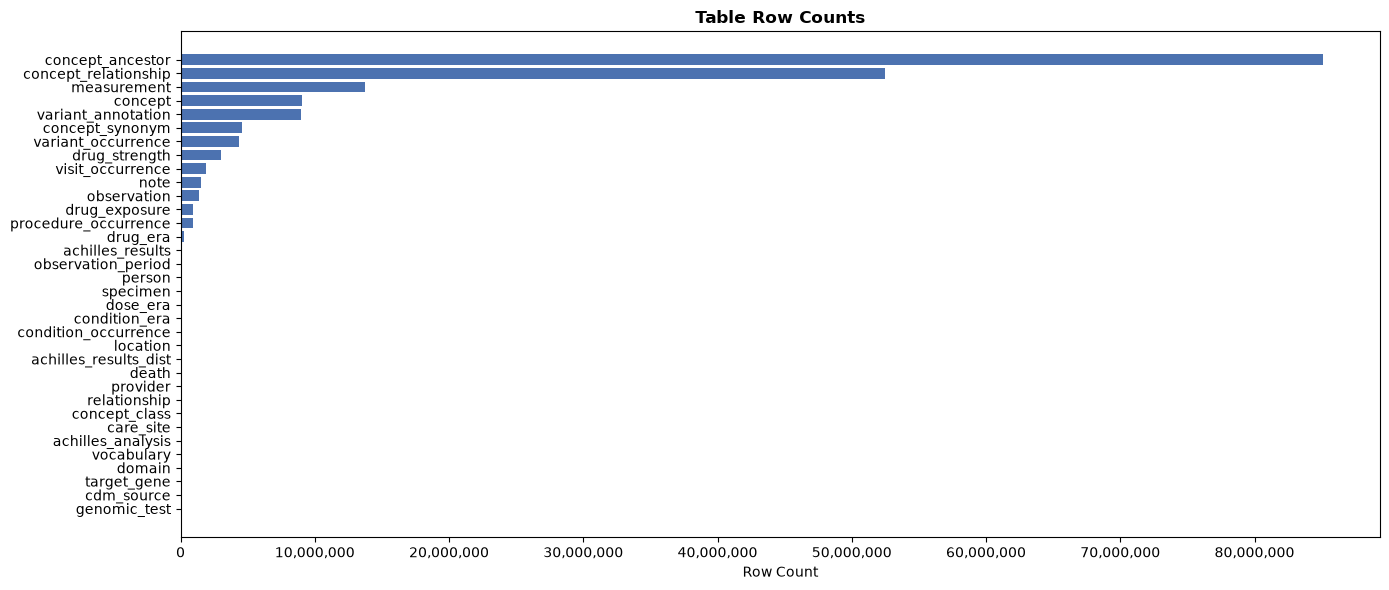

Total tables : 43
Non-empty    : 34


,table,row_count
0,concept_ancestor,"85,093,454"
1,concept_relationship,"52,444,122"
2,measurement,"13,714,401"
3,concept,"9,018,807"
4,variant_annotation,"8,969,888"
5,concept_synonym,"4,564,919"
6,variant_occurrence,"4,343,236"
7,drug_strength,"3,020,774"
8,visit_occurrence,"1,929,158"
9,note,"1,499,925"


In [2]:
# Get the names of all available OMOP tables
tables = list_omop_tables()

# Store the row count for each table
table_counts = []

for table_name in tables:
    table = get_table(table_name)
    row_count = table.count().execute()

    table_counts.append({
        "table": table_name,
        "row_count": row_count
    })

# Create a summary ordered from largest to smallest
overview = (
    pd.DataFrame(table_counts)
    .sort_values("row_count", ascending=False)
    .reset_index(drop=True)
)

# Select non-empty tables for the chart
non_zero = overview.loc[
    overview["row_count"] > 0
].copy()

# Plot row counts for non-empty tables
fig, ax = plt.subplots(figsize=(14, 6))

ax.barh(
    non_zero["table"],
    non_zero["row_count"],
    color=PALETTE[0]
)

ax.set_title(
    "Table Row Counts",
    fontweight="bold"
)
ax.set_xlabel("Row Count")

# Format large values using comma separators
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda value, _: f"{int(value):,}"
    )
)

# Display the largest tables at the top
ax.invert_yaxis()

plt.tight_layout()
plt.show()

# Print the database summary
print(f"Total tables : {len(overview)}")
print(f"Non-empty    : {len(non_zero)}")

# Create a formatted copy for display
overview_display = overview.copy()
overview_display["row_count"] = (
    overview_display["row_count"]
    .map("{:,}".format)
)

overview_display

## Loading and Preparing Patient Demographics

This cell loads the OMOP `person` and `concept` tables for reuse throughout the notebook. The `person` table contains patient demographic information, while the `concept` table provides readable names for coded OMOP values.

A helper function is used to convert the coded gender, race, and ethnicity fields into readable labels. Left joins are used so that all patient records remain in the dataset, even when a concept ID cannot be matched.

An approximate age is calculated by subtracting the recorded year of birth from the dataset reference year, 2024. The cell then reports the total number of patients and the number of missing labels in each demographic field.

Age is approximate because only the year of birth is used rather than the complete date of birth. No patients are removed in this step.


In [3]:
# Load core OMOP tables for reuse throughout the notebook
person = get_table("person").execute()
concept = get_table("concept").execute()


def add_demographic_label(data, domain, source_column, output_column):
    concept_map = (
        concept.loc[
            concept["domain_id"].eq(domain),
            ["concept_id", "concept_name"]
        ]
        .rename(columns={
            "concept_id": f"{output_column}_concept_id",
            "concept_name": output_column
        })
    )

    # Use a left join to retain all patient records
    data = data.merge(
        concept_map,
        left_on=source_column,
        right_on=f"{output_column}_concept_id",
        how="left"
    )

    # Remove the duplicate concept ID added during the merge
    return data.drop(columns=f"{output_column}_concept_id")


# Convert demographic concept IDs into readable labels
person = add_demographic_label(
    person,
    domain="Gender",
    source_column="gender_concept_id",
    output_column="gender"
)

person = add_demographic_label(
    person,
    domain="Race",
    source_column="race_concept_id",
    output_column="race"
)

person = add_demographic_label(
    person,
    domain="Ethnicity",
    source_column="ethnicity_concept_id",
    output_column="ethnicity"
)

# Calculate approximate age using the synthetic dataset reference year
REFERENCE_YEAR = 2024
person["age"] = REFERENCE_YEAR - person["year_of_birth"]

# Display demographic data quality checks
print(f"Persons loaded : {len(person):,}")
print(f"Gender nulls   : {person['gender'].isna().sum():,}")
print(f"Race nulls     : {person['race'].isna().sum():,}")
print(f"Ethnicity nulls: {person['ethnicity'].isna().sum():,}")

Persons loaded : 99,523
Gender nulls   : 0
Race nulls     : 11,704
Ethnicity nulls: 99,523


## Exploring Patient Demographics

This cell visualises the age, gender, and race distributions of the patient cohort using three plots.

The age histogram shows how patients are distributed across different ages, with a dashed line marking the median age. The gender chart presents the number and percentage of patients in each recorded category. The race chart displays the number of patients in each mapped race category and reports how many records have missing or unmapped race information.

Summary statistics are printed below the plots, including the total number of patients, age range, mean and median age, gender counts, and race counts.

Missing age and race values are excluded only from their relevant plots and calculations. They are not removed from the `person` dataset.

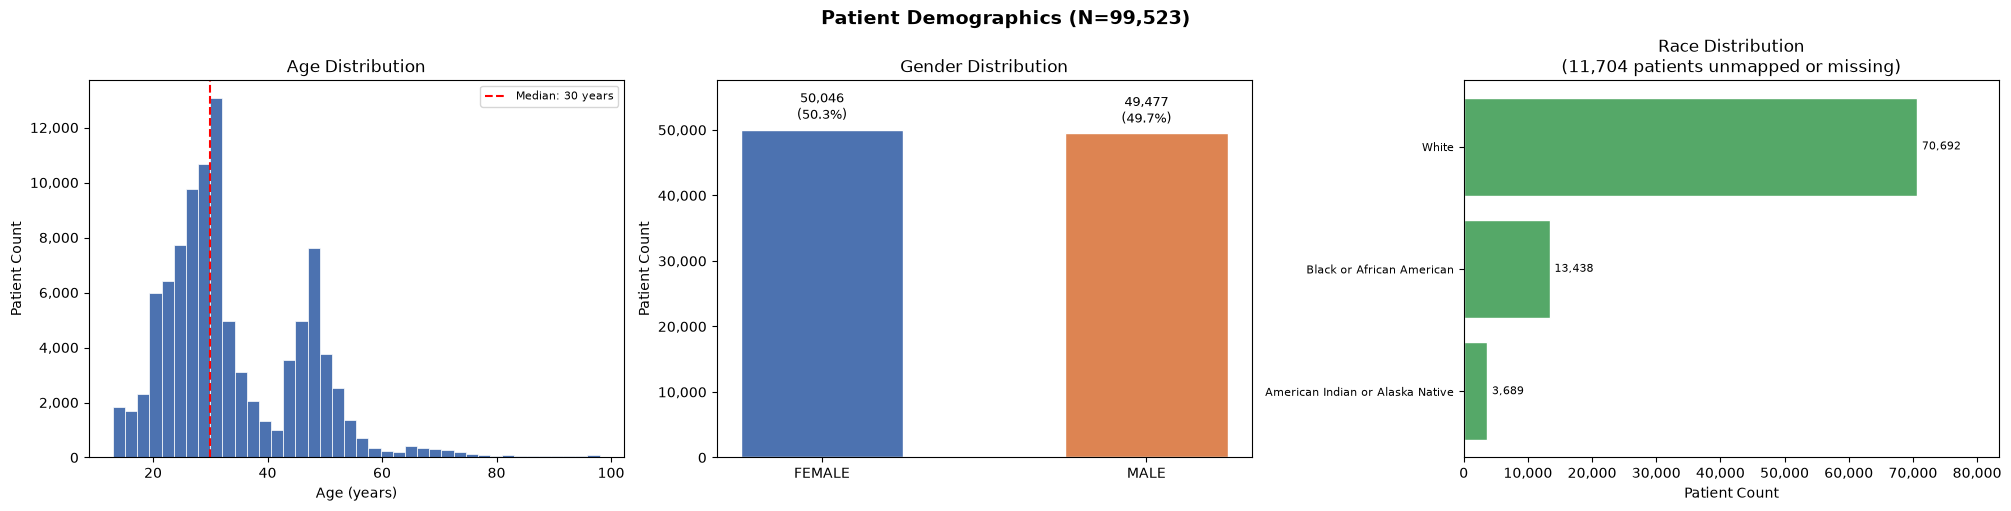

Total patients : 99,523
Age range      : 13–98 years | Median: 30 | Mean: 33.9

Gender:
gender
FEMALE    50046
MALE      49477

Race mapped    : 87,819 patients | Unmapped/null: 11,704
race
White                               70692
Black or African American           13438
American Indian or Alaska Native     3689


In [4]:
# Create age, gender, and race plots in one figure
fig, axes = plt.subplots(
    1, 3,
    figsize=(20, 5),
    constrained_layout=True
)

ax_age, ax_gender, ax_race = axes

fig.suptitle(
    f"Patient Demographics (N={len(person):,})",
    fontsize=14,
    fontweight="bold"
)

# Age distribution
# Exclude missing ages from the age summary and plot
age_data = person["age"].dropna()
median_age = age_data.median()

ax_age.hist(
    age_data,
    bins=40,
    color=PALETTE[0],
    edgecolor="white",
    linewidth=0.5
)

ax_age.axvline(
    median_age,
    color="red",
    linestyle="--",
    label=f"Median: {median_age:.0f} years"
)

ax_age.set_title("Age Distribution")
ax_age.set_xlabel("Age (years)")
ax_age.set_ylabel("Patient Count")
ax_age.legend(fontsize=8)

ax_age.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda value, _: f"{int(value):,}")
)

# Gender distribution
# Count patients in each mapped gender category
gender_counts = person["gender"].value_counts()

gender_bars = ax_gender.bar(
    gender_counts.index,
    gender_counts.values,
    color=[
        PALETTE[index % len(PALETTE)]
        for index in range(len(gender_counts))
    ],
    edgecolor="white",
    width=0.5
)

ax_gender.set_title("Gender Distribution")
ax_gender.set_ylabel("Patient Count")
ax_gender.set_ylim(0, gender_counts.max() * 1.15)

# Add patient counts and cohort percentages above each bar
for bar, count in zip(gender_bars, gender_counts.values):
    percentage = count / len(person) * 100

    ax_gender.text(
        bar.get_x() + bar.get_width() / 2,
        count + gender_counts.max() * 0.02,
        f"{count:,}\n({percentage:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax_gender.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda value, _: f"{int(value):,}")
)

# Race distribution
# Exclude missing race labels from the chart
race_counts = person["race"].dropna().value_counts()
race_nulls = person["race"].isna().sum()

# Shorten long race labels for readability
race_labels = [
    f"{label[:32]}…" if len(label) > 32 else label
    for label in race_counts.index
]

race_bars = ax_race.barh(
    race_labels,
    race_counts.values,
    color=PALETTE[2],
    edgecolor="white"
)

ax_race.set_title(
    f"Race Distribution\n"
    f"({race_nulls:,} patients unmapped or missing)"
)
ax_race.set_xlabel("Patient Count")
ax_race.invert_yaxis()
ax_race.tick_params(axis="y", labelsize=8)

ax_race.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda value, _: f"{int(value):,}")
)

# Add patient counts to the end of each bar
for bar, count in zip(race_bars, race_counts.values):
    ax_race.text(
        count + race_counts.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,}",
        va="center",
        fontsize=8
    )

ax_race.set_xlim(0, race_counts.max() * 1.18)

plt.show()

# Print demographic summary statistics
print(f"Total patients : {len(person):,}")
print(
    f"Age range      : {age_data.min():.0f}–{age_data.max():.0f} years | "
    f"Median: {median_age:.0f} | "
    f"Mean: {age_data.mean():.1f}"
)

print("\nGender:")
print(gender_counts.to_string())

print(
    f"\nRace mapped    : {race_counts.sum():,} patients | "
    f"Unmapped/null: {race_nulls:,}"
)
print(race_counts.to_string())

## Loading the Main Clinical Tables

This cell loads the main OMOP tables required for the clinical analysis. These tables contain recorded conditions, medication exposures, healthcare visits, procedures, measurements, observations, and clinical notes.

The tables are stored in a dictionary and are also assigned shorter variable names to make the later analysis easier to read. Relevant date columns are converted into pandas datetime format so that clinical events can later be sorted, filtered, and compared across time.

Any invalid or unrecognised date values are converted to missing datetime values rather than causing the notebook to stop. Finally, the number of records loaded from each table is printed as an initial data availability check.

No clinical records are removed in this cell.


In [5]:
# Load the main OMOP clinical tables
clinical_tables = {
    "condition_occurrence": get_table("condition_occurrence").execute(),
    "drug_exposure": get_table("drug_exposure").execute(),
    "visit_occurrence": get_table("visit_occurrence").execute(),
    "procedure_occurrence": get_table("procedure_occurrence").execute(),
    "measurement": get_table("measurement").execute(),
    "observation": get_table("observation").execute(),
    "note": get_table("note").execute()
}

# Define the date column used in each clinical table
date_columns = {
    "condition_occurrence": "condition_start_date",
    "drug_exposure": "drug_exposure_start_date",
    "visit_occurrence": "visit_start_date",
    "procedure_occurrence": "procedure_date",
    "measurement": "measurement_date",
    "observation": "observation_date",
    "note": "note_date"
}

# Convert available date columns into pandas datetime format
for table_name, date_column in date_columns.items():
    dataframe = clinical_tables[table_name]

    if date_column in dataframe.columns:
        dataframe[date_column] = pd.to_datetime(
            dataframe[date_column],
            errors="coerce"
        )

# Create shorter variable names for later analysis
co = clinical_tables["condition_occurrence"]
de = clinical_tables["drug_exposure"]
vo = clinical_tables["visit_occurrence"]
po = clinical_tables["procedure_occurrence"]
me = clinical_tables["measurement"]
obs = clinical_tables["observation"]
note = clinical_tables["note"]

# Display the number of records loaded from each table
print("Clinical tables loaded:")

for table_name, dataframe in clinical_tables.items():
    print(f"  {table_name:<30} {len(dataframe):>12,} rows")

Clinical tables loaded:
  condition_occurrence                 39,306 rows
  drug_exposure                       962,858 rows
  visit_occurrence                  1,929,158 rows
  procedure_occurrence                914,952 rows
  measurement                      13,714,401 rows
  observation                       1,370,251 rows
  note                              1,499,925 rows


## Distribution of Clinical Events per Patient

This cell examines how many clinical records are available for each patient across six OMOP domains: medications, visits, procedures, measurements, observations, and clinical notes.

For each domain, records are grouped by `person_id` and counted. A histogram is then used to show how these event counts are distributed across patients. The red dashed line represents the median number of events among patients with at least one record in that domain.

A summary table is also printed for all domains, including conditions. It reports the total number of records and the median, mean, and maximum number of events per patient.

Patients with no records in a particular domain are not included in that domain’s histogram or summary statistics. Therefore, the results describe patients with at least one recorded event rather than the complete patient cohort.


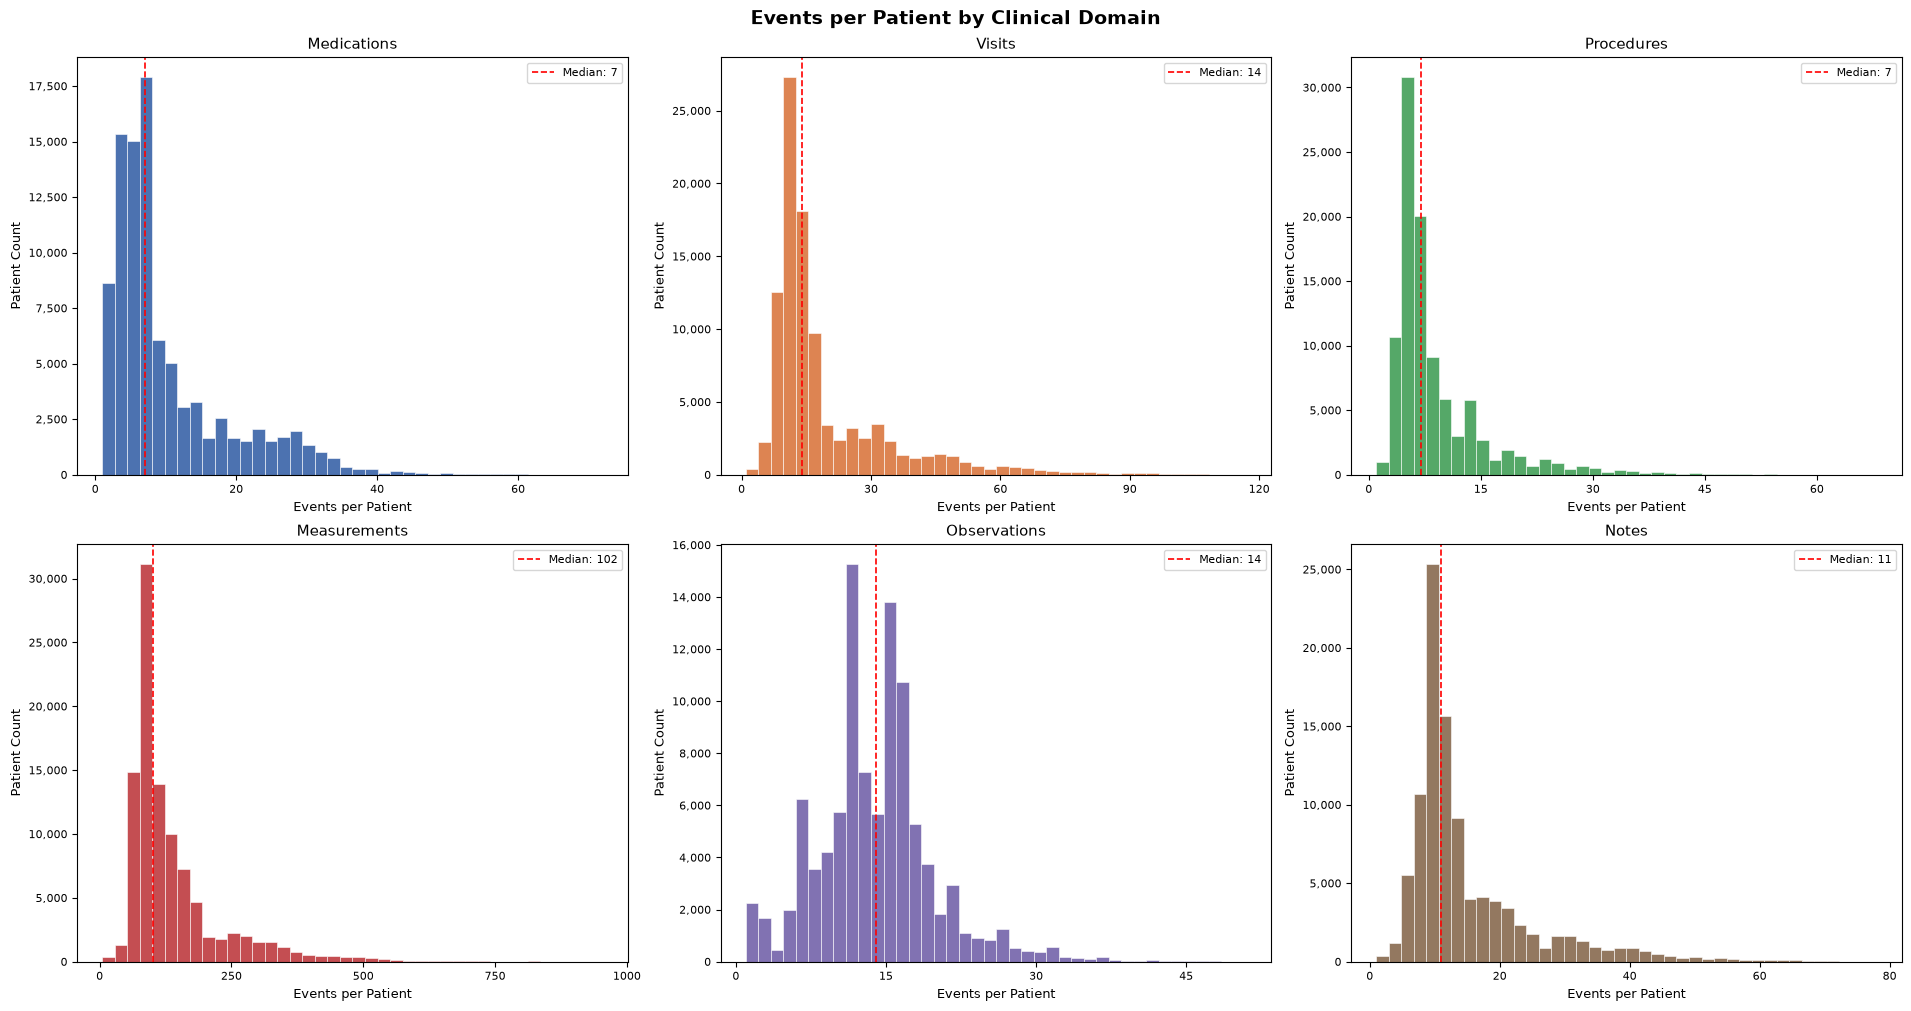

Domain                 Total    Median/pt      Mean/pt     Max/pt
-----------------------------------------------------------------
Conditions            39,306          1.0          1.7          5
Medications          962,858          7.0         10.3         72
Visits             1,929,158         14.0         19.4        117
Procedures           914,952          7.0          9.2         68
Measurements      13,714,401        102.0        137.8        954
Observations       1,370,251         14.0         13.8         51
Notes              1,499,925         11.0         15.1         78


In [6]:
# Count records per patient across the main clinical domains
domain_counts = {
    "Medications": de.groupby("person_id").size(),
    "Visits": vo.groupby("person_id").size(),
    "Procedures": po.groupby("person_id").size(),
    "Measurements": me.groupby("person_id").size(),
    "Observations": obs.groupby("person_id").size(),
    "Notes": note.groupby("person_id").size()
}

# Create one histogram for each clinical domain
fig, axes = plt.subplots(
    2, 3,
    figsize=(19, 10),
    constrained_layout=True
)

fig.suptitle(
    "Events per Patient by Clinical Domain",
    fontsize=14,
    fontweight="bold"
)

# Plot the event-count distribution for each domain
for index, (domain, event_counts) in enumerate(domain_counts.items()):
    ax = axes.flat[index]
    median_count = event_counts.median()

    ax.hist(
        event_counts,
        bins=40,
        color=PALETTE[index % len(PALETTE)],
        edgecolor="white",
        linewidth=0.4
    )

    # Mark the median number of events
    ax.axvline(
        median_count,
        color="red",
        linestyle="--",
        linewidth=1.2,
        label=f"Median: {median_count:.0f}"
    )

    ax.set_title(domain, fontsize=11)
    ax.set_xlabel("Events per Patient", fontsize=9)
    ax.set_ylabel("Patient Count", fontsize=9)
    ax.legend(fontsize=8)
    ax.tick_params(axis="both", labelsize=8)

    # Format axes for easier interpretation
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda value, _: f"{int(value):,}")
    )
    ax.xaxis.set_major_locator(
        mticker.MaxNLocator(nbins=5, integer=True)
    )

plt.show()

# Include condition records in the printed summary
all_domain_counts = {
    "Conditions": co.groupby("person_id").size(),
    **domain_counts
}

# Print summary statistics for each domain
print(
    f"{'Domain':<15} {'Total':>12} {'Median/pt':>12} "
    f"{'Mean/pt':>12} {'Max/pt':>10}"
)
print("-" * 65)

for domain, event_counts in all_domain_counts.items():
    print(
        f"{domain:<15} "
        f"{event_counts.sum():>12,} "
        f"{event_counts.median():>12.1f} "
        f"{event_counts.mean():>12.1f} "
        f"{event_counts.max():>10,}"
    )

## Identifying the Most Common Conditions

This cell links the coded condition records in the `condition_occurrence` table to readable condition names using the OMOP `concept` table. Records without a matching concept name are retained and labelled as unmapped rather than being removed.

For each condition, two values are calculated: the total number of condition records and the number of unique patients affected. Counting unique patients prevents a patient with repeated records for the same condition from being counted multiple times in the patient total.

The 20 conditions affecting the largest number of patients are displayed in a horizontal bar chart. A separate table prints detailed counts for the top 10 conditions.

The ranking is based on unique patient count rather than the total number of condition records. Only the displayed results are limited to the top conditions; the full `co_named` dataset remains unchanged.


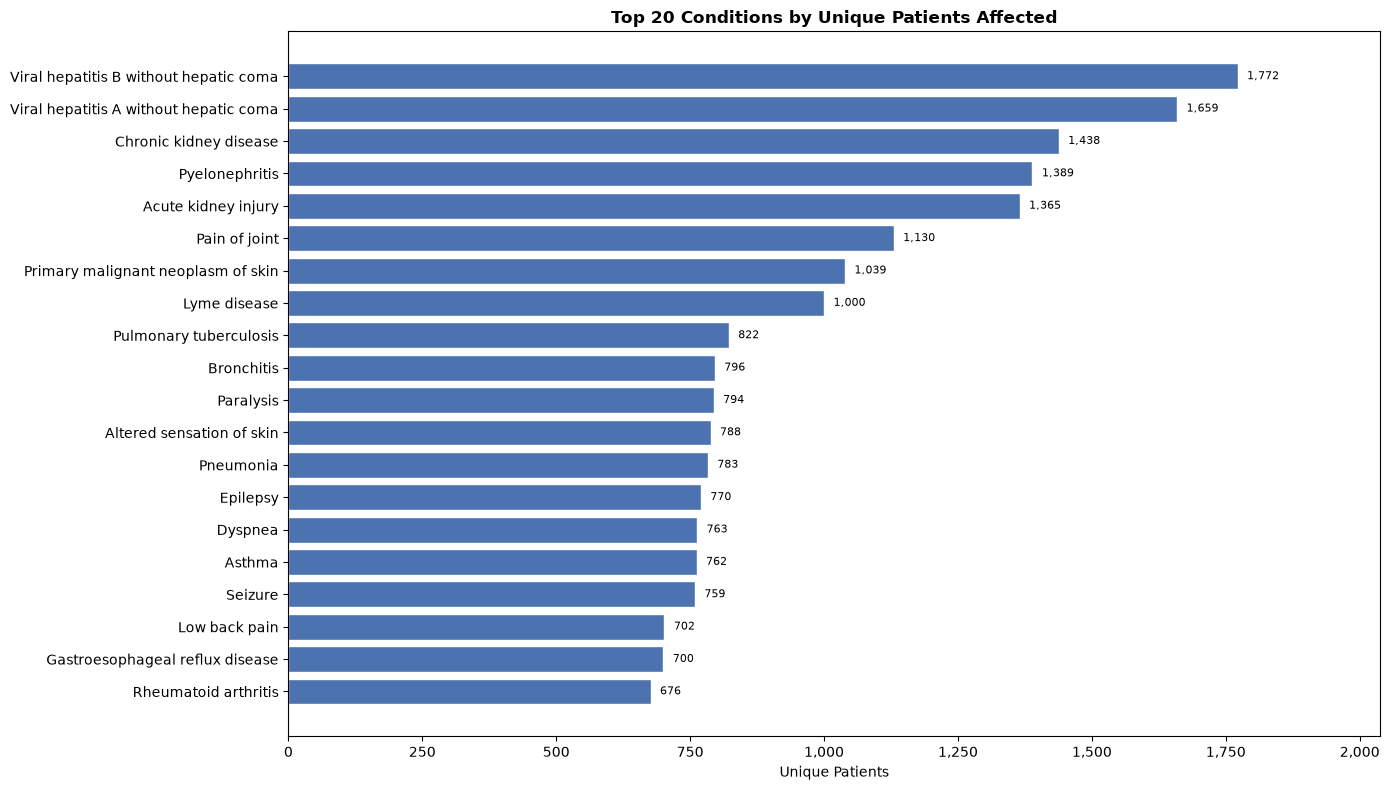

Top 10 Conditions by Unique Patient Count:
                          concept_name  patient_count  occurrence_count
Viral hepatitis B without hepatic coma           1772              1772
Viral hepatitis A without hepatic coma           1659              1659
                Chronic kidney disease           1438              1438
                        Pyelonephritis           1389              1389
                   Acute kidney injury           1365              1365
                         Pain of joint           1130              1130
    Primary malignant neoplasm of skin           1039              1039
                          Lyme disease           1000              1000
                Pulmonary tuberculosis            822               822
                            Bronchitis            796               796


In [7]:
# Add readable condition names using the OMOP concept table
co_named = co.merge(
    concept[["concept_id", "concept_name"]],
    left_on="condition_concept_id",
    right_on="concept_id",
    how="left"
)

# Retain condition records without a matching concept name
co_named["concept_name"] = co_named["concept_name"].fillna(
    "Unmapped or missing condition"
)

# Count condition records and unique patients for each condition
condition_summary = (
    co_named.groupby("concept_name", as_index=False)
    .agg(
        occurrence_count=("condition_occurrence_id", "count"),
        patient_count=("person_id", "nunique")
    )
    .sort_values(
        ["patient_count", "occurrence_count"],
        ascending=False
    )
)

# Select the 20 conditions affecting the most patients
top_conditions = condition_summary.head(20).copy()

# Plot the most common conditions by unique patient count
fig, ax = plt.subplots(figsize=(14, 8))

bars = ax.barh(
    top_conditions["concept_name"],
    top_conditions["patient_count"],
    color=PALETTE[0],
    edgecolor="white"
)

ax.set_title(
    "Top 20 Conditions by Unique Patients Affected",
    fontweight="bold"
)
ax.set_xlabel("Unique Patients")
ax.invert_yaxis()

# Format patient counts with comma separators
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda value, _: f"{int(value):,}")
)

# Add patient counts to the end of each bar
label_offset = top_conditions["patient_count"].max() * 0.01

for bar, count in zip(bars, top_conditions["patient_count"]):
    ax.text(
        count + label_offset,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,}",
        va="center",
        fontsize=8
    )

ax.set_xlim(
    0,
    top_conditions["patient_count"].max() * 1.15
)

plt.tight_layout()
plt.show()

# Display detailed results for the 10 most common conditions
print("Top 10 Conditions by Unique Patient Count:")
print(
    top_conditions[
        ["concept_name", "patient_count", "occurrence_count"]
    ]
    .head(10)
    .to_string(index=False)
)

## Identifying the Most Common Medications

This cell links medication concept IDs in the `drug_exposure` table to readable medication names using the OMOP `concept` table. Medication records without a matching concept name are retained and labelled as unmapped.

For each medication, the code calculates both the total number of exposure records and the number of unique patients with at least one recorded exposure. Unique patient counts are used for ranking so that repeated prescriptions or administrations for the same patient do not increase the patient total.

The 20 medications recorded for the largest number of patients are displayed in a horizontal bar chart. Long medication names are wrapped to improve readability, while a shorter version is used in the printed summary of the top 10 medications.

The chart is limited to the top 20 medications, but the underlying medication records are not removed or changed.


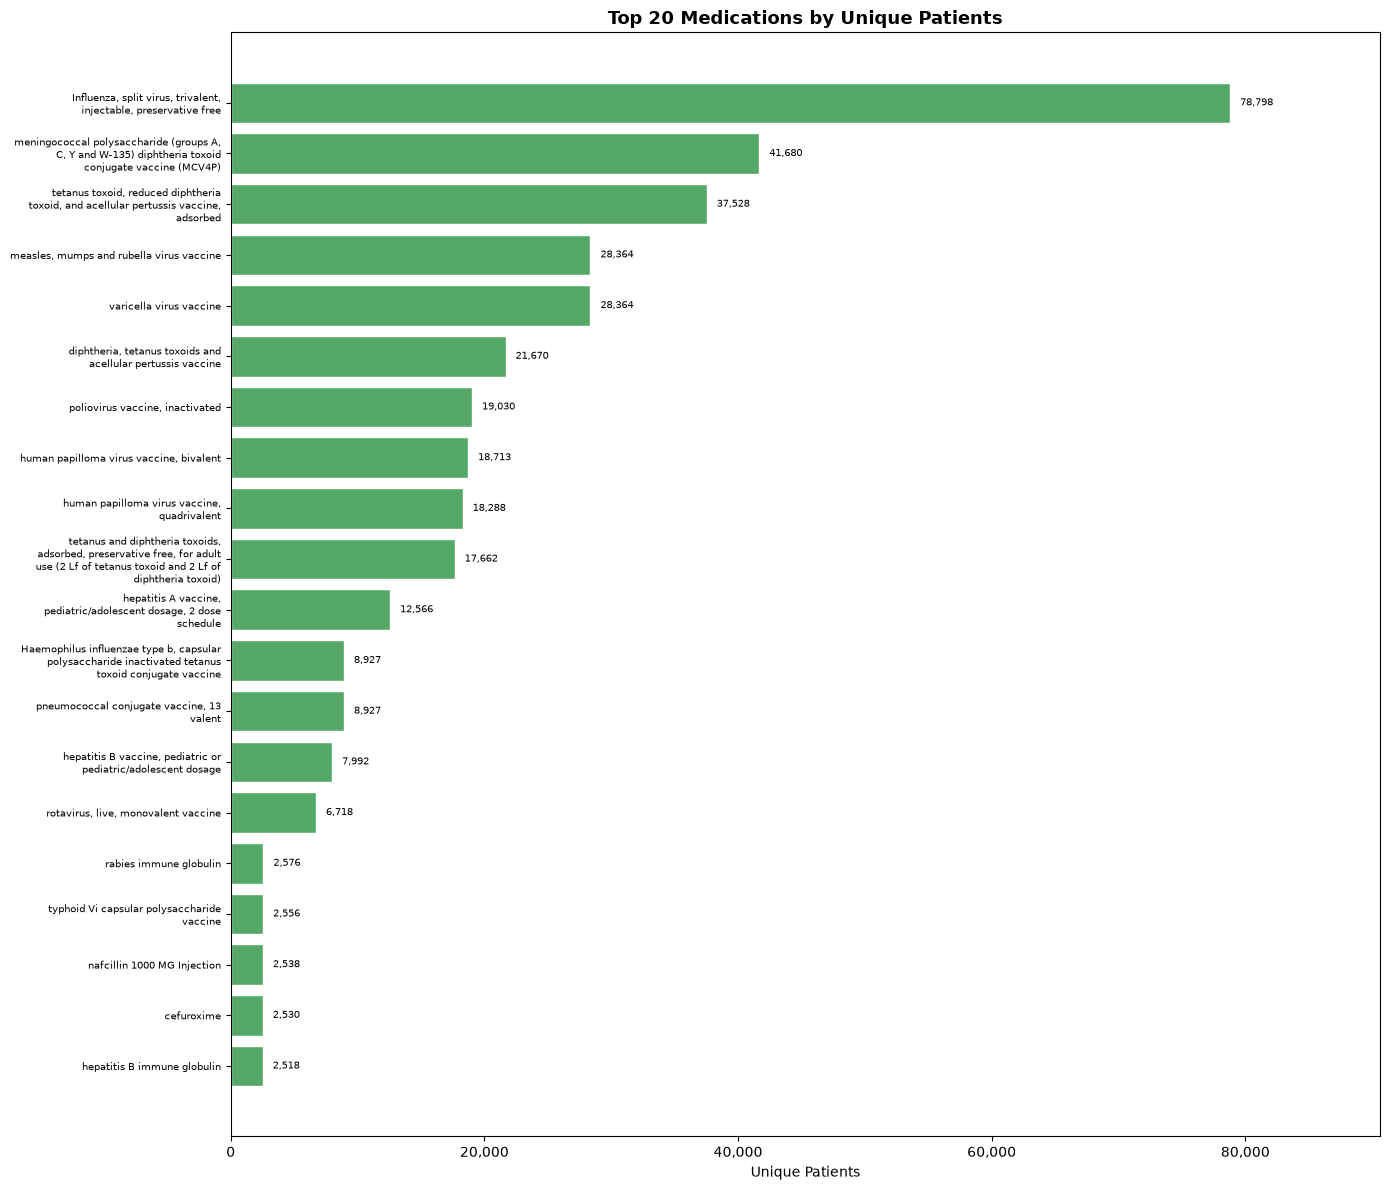

Top 10 Medications by Unique Patient Count:
Medication                                                  Patients    Exposures
----------------------------------------------------------------------------------
Influenza, split virus, trivalent, injectable,...             78,798      205,561
meningococcal polysaccharide (groups A, C, Y and...           41,680       46,559
tetanus toxoid, reduced diphtheria toxoid, and...             37,528       37,528
measles, mumps and rubella virus vaccine                      28,364       34,334
varicella virus vaccine                                       28,364       34,334
diphtheria, tetanus toxoids and acellular pertussis...        21,670       46,958
poliovirus vaccine, inactivated                               19,030       36,001
human papilloma virus vaccine, bivalent                       18,713       44,059
human papilloma virus vaccine, quadrivalent                   18,288       42,973
tetanus and diphtheria toxoids, adsorbed,...         

In [8]:
# Add readable medication names using the OMOP concept table
de_named = de.merge(
    concept[["concept_id", "concept_name"]],
    left_on="drug_concept_id",
    right_on="concept_id",
    how="left"
)

# Retain medication records without a matching concept name
de_named["concept_name"] = de_named["concept_name"].fillna(
    "Unmapped or missing medication"
)

# Count exposure records and unique patients for each medication
medication_summary = (
    de_named.groupby("concept_name", as_index=False)
    .agg(
        exposure_count=("drug_exposure_id", "count"),
        patient_count=("person_id", "nunique")
    )
    .sort_values(
        ["patient_count", "exposure_count"],
        ascending=False
    )
)

# Select the 20 medications recorded for the most patients
top_meds = medication_summary.head(20).copy()

# Wrap long medication names for chart labels
top_meds["label"] = top_meds["concept_name"].apply(
    lambda name: "\n".join(
        textwrap.wrap(str(name), width=40)
    )
)

# Plot the top medications by unique patient count
fig, ax = plt.subplots(figsize=(14, 12))

y_positions = range(len(top_meds))

bars = ax.barh(
    y_positions,
    top_meds["patient_count"],
    color=PALETTE[2],
    edgecolor="white"
)

ax.set_yticks(y_positions)
ax.set_yticklabels(top_meds["label"], fontsize=7.5)
ax.set_title(
    "Top 20 Medications by Unique Patients",
    fontsize=13,
    fontweight="bold"
)
ax.set_xlabel("Unique Patients")
ax.invert_yaxis()

# Format patient counts with comma separators
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda value, _: f"{int(value):,}")
)

# Add patient counts to the end of each bar
label_offset = top_meds["patient_count"].max() * 0.01

for bar, count in zip(bars, top_meds["patient_count"]):
    ax.text(
        count + label_offset,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,}",
        va="center",
        fontsize=7
    )

ax.set_xlim(
    0,
    top_meds["patient_count"].max() * 1.15
)

plt.tight_layout()
plt.show()

# Shorten medication names for the printed summary
top_meds["short_name"] = top_meds["concept_name"].apply(
    lambda name: textwrap.shorten(
        str(name),
        width=55,
        placeholder="..."
    )
)

# Display detailed results for the 10 most common medications
print("Top 10 Medications by Unique Patient Count:")
print(f"{'Medication':<57} {'Patients':>10} {'Exposures':>12}")
print("-" * 82)

for row in top_meds.head(10).itertuples(index=False):
    print(
        f"{row.short_name:<57} "
        f"{row.patient_count:>10,} "
        f"{row.exposure_count:>12,}"
    )

## Exploring Common Numeric Measurements

This cell links measurement concept IDs to readable names using the OMOP `concept` table. Records without a matching concept name are retained and labelled as unmapped.

Only measurements containing a value in `value_as_number` are included because histograms require numeric results. The eight most frequently recorded numeric measurement types are then identified and displayed in separate histograms.

For each measurement, the interquartile range is used to limit the effect of extreme values on the visualisation. Values outside three interquartile ranges from the lower or upper quartile are excluded from the relevant histogram only. They remain unchanged in the original measurement dataset.

The most commonly recorded unit is added to each axis label where unit information is available. The cell also prints the total number of numeric measurement records, the number of unique measurement types, and the eight most frequently recorded measurements.


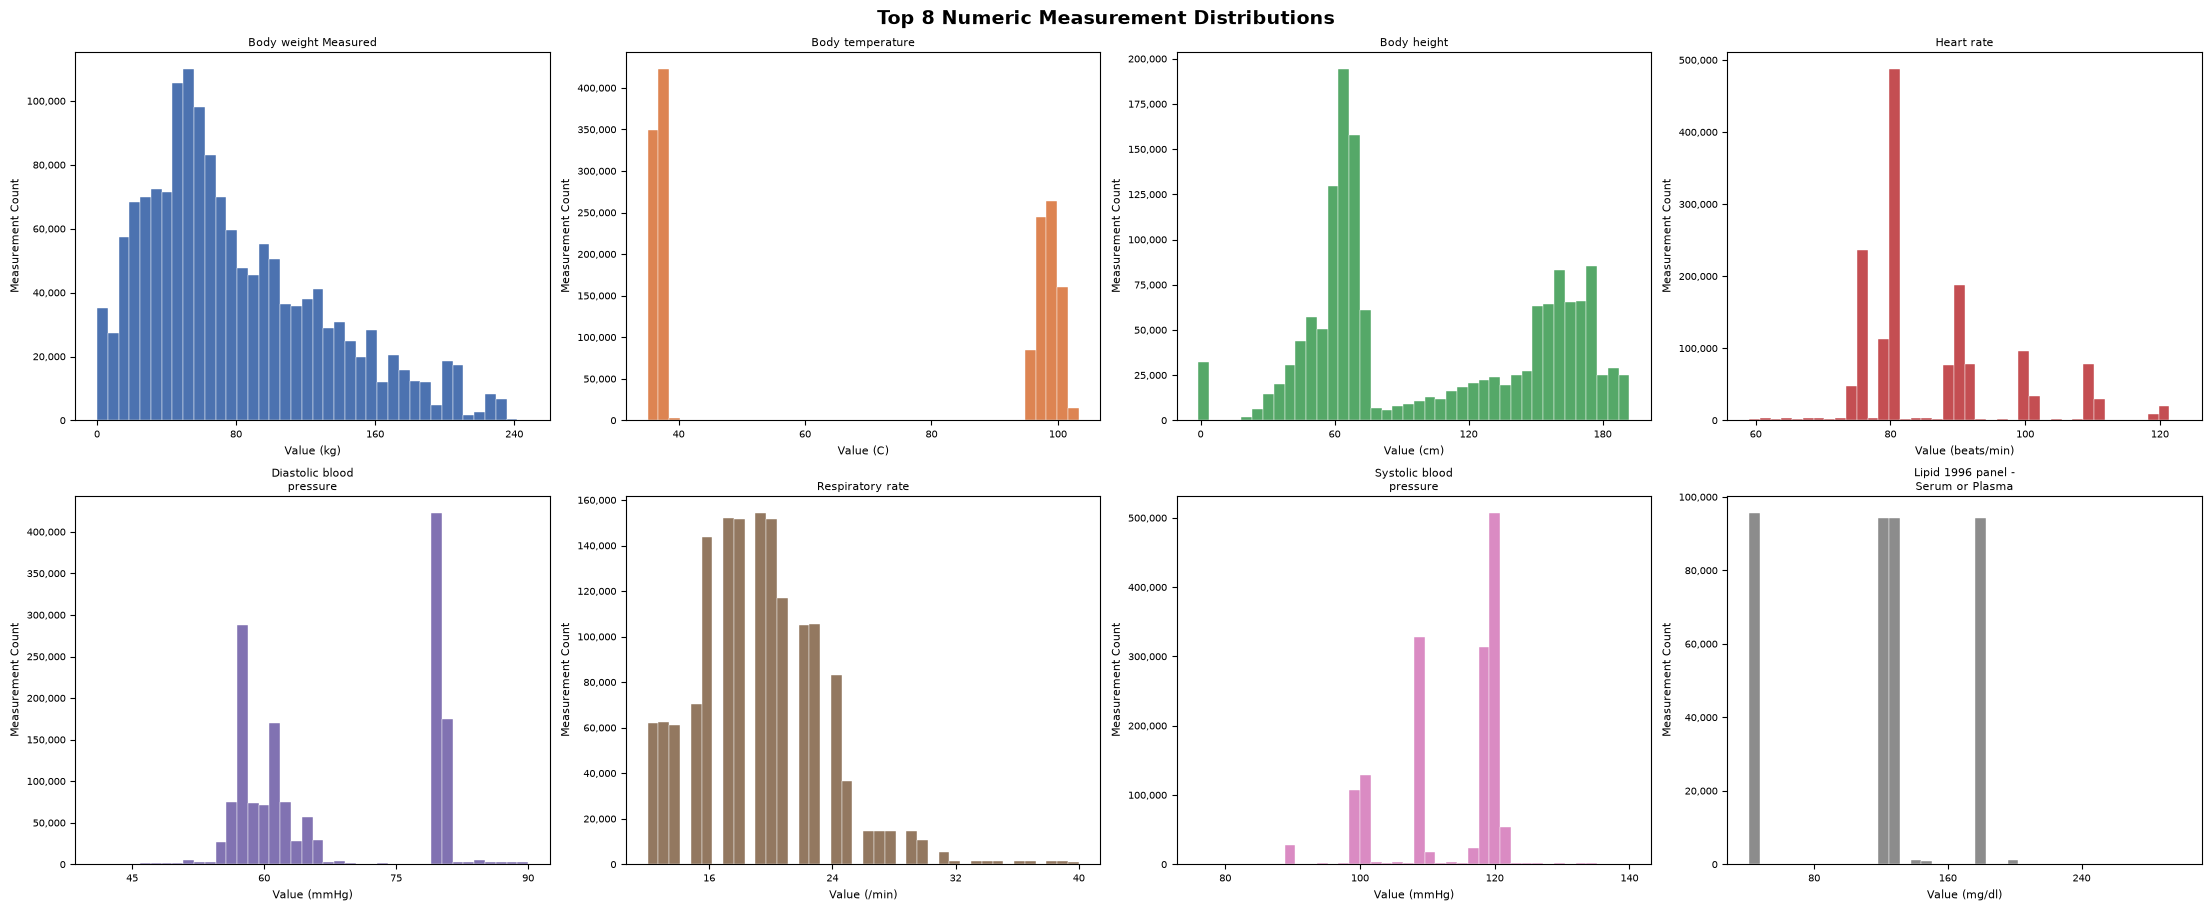

Total measurements with numeric values : 12,999,335
Unique numeric measurement types       : 115

Top 8 numeric measurement types by record count:
                      concept_name   count
              Body weight Measured 1544814
                  Body temperature 1544814
                       Body height 1544814
                        Heart rate 1544814
          Diastolic blood pressure 1544814
                  Respiratory rate 1544814
           Systolic blood pressure 1544814
Lipid 1996 panel - Serum or Plasma  382065


In [9]:
# Add readable measurement names using the OMOP concept table
me_named = me.merge(
    concept[["concept_id", "concept_name"]],
    left_on="measurement_concept_id",
    right_on="concept_id",
    how="left"
)

# Retain records without a matching measurement name
me_named["concept_name"] = me_named["concept_name"].fillna(
    "Unmapped measurement"
)

# Keep measurements containing numeric results
numeric_measurements = me_named.loc[
    me_named["value_as_number"].notna()
].copy()

# Identify the eight most frequently recorded numeric measurements
top_measurements = (
    numeric_measurements
    .groupby("concept_name", as_index=False)
    .agg(count=("measurement_id", "count"))
    .sort_values("count", ascending=False)
    .head(8)
)

# Create one histogram for each measurement type
fig, axes = plt.subplots(
    2, 4,
    figsize=(22, 9),
    constrained_layout=True
)

fig.suptitle(
    "Top 8 Numeric Measurement Distributions",
    fontsize=14,
    fontweight="bold"
)

for plot_index, (_, measurement) in enumerate(top_measurements.iterrows()):
    ax = axes.flat[plot_index]
    measurement_name = measurement["concept_name"]

    # Select values for the current measurement
    values = numeric_measurements.loc[
        numeric_measurements["concept_name"].eq(measurement_name),
        "value_as_number"
    ]

    # Calculate limits based on three interquartile ranges
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1

    if iqr > 0:
        lower_limit = q1 - 3 * iqr
        upper_limit = q3 + 3 * iqr
        plot_values = values[
            values.between(lower_limit, upper_limit)
        ]
    else:
        plot_values = values

    # Plot the filtered distribution
    ax.hist(
        plot_values,
        bins=40,
        color=PALETTE[plot_index % len(PALETTE)],
        edgecolor="white",
        linewidth=0.3
    )

    # Wrap long measurement names across multiple lines
    wrapped_title = "\n".join(
        textwrap.wrap(str(measurement_name), width=22)
    )
    ax.set_title(wrapped_title, fontsize=8, pad=4)

    # Use the most frequently recorded source unit where available
    unit_label = ""

    if "unit_source_value" in numeric_measurements.columns:
        units = numeric_measurements.loc[
            numeric_measurements["concept_name"].eq(measurement_name),
            "unit_source_value"
        ].dropna()

        units = units[
            units.astype(str).str.strip().ne("")
        ]

        unit_mode = units.mode()

        if not unit_mode.empty:
            unit_label = f" ({unit_mode.iloc[0]})"

    ax.set_xlabel(f"Value{unit_label}", fontsize=8)
    ax.set_ylabel("Measurement Count", fontsize=8)
    ax.tick_params(axis="both", labelsize=7)

    ax.xaxis.set_major_locator(
        mticker.MaxNLocator(nbins=4)
    )
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda value, _: f"{int(value):,}")
    )

# Hide unused plots when fewer than eight measurement types are available
for unused_index in range(len(top_measurements), len(axes.flat)):
    axes.flat[unused_index].set_visible(False)

plt.show()

# Print the measurement summary
print(
    f"Total measurements with numeric values : "
    f"{len(numeric_measurements):,}"
)
print(
    f"Unique numeric measurement types       : "
    f"{numeric_measurements['concept_name'].nunique():,}"
)

print("\nTop 8 numeric measurement types by record count:")
print(top_measurements.to_string(index=False))

## Number of Recorded Conditions per Patient

This cell calculates the number of distinct conditions recorded for each patient. The analysis begins with the complete `person` table so that patients without any condition records are also included.

Condition records are grouped by `person_id`, and unique condition concept IDs are counted. These counts are then merged with the full patient list using a left join. Patients without a matching condition record are assigned a condition count of zero.

A histogram displays the distribution of condition counts across the full cohort. Patients are also grouped into categories ranging from no recorded conditions to ten or more conditions, and the number and percentage of patients in each category are printed.

The condition count provides an indication of recorded disease burden. However, it should not automatically be interpreted as confirmed multimorbidity because the data may include repeated, historical, acute, or non-long-term conditions.


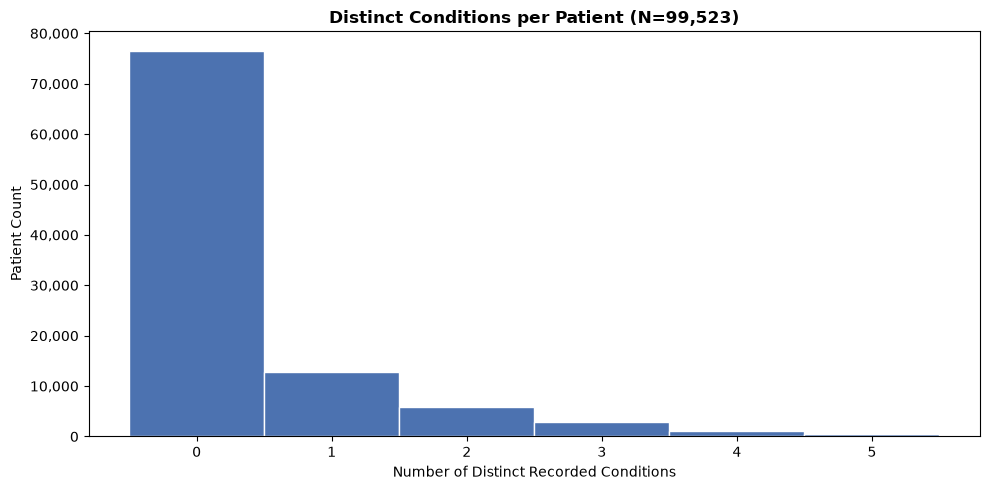

Recorded condition distribution (all 99,523 patients):
  0 conditions           76,573 patients (76.9%)
  1 condition            12,884 patients (12.9%)
  2 conditions            5,761 patients (5.8%)
  3–4 conditions          3,809 patients (3.8%)
  5–9 conditions            496 patients (0.5%)
  10+ conditions              0 patients (0.0%)


In [10]:
# Use the full patient list so patients with no conditions are included
conditions_per_patient = person[
    ["person_id", "age", "gender"]
].copy()

# Exclude missing and non-standard condition concept IDs
valid_conditions = co.loc[
    co["condition_concept_id"].notna()
    & co["condition_concept_id"].ne(0)
].copy()

# Count distinct condition concepts recorded for each patient
condition_counts = (
    valid_conditions
    .groupby("person_id")["condition_concept_id"]
    .nunique()
    .reset_index(name="condition_count")
)

# Merge condition counts with the complete patient cohort
conditions_per_patient = conditions_per_patient.merge(
    condition_counts,
    on="person_id",
    how="left"
)

# Assign zero to patients without recorded conditions
conditions_per_patient["condition_count"] = (
    conditions_per_patient["condition_count"]
    .fillna(0)
    .astype(int)
)

# Create bins centred on whole-number condition counts
maximum_count = conditions_per_patient["condition_count"].max()
histogram_bins = np.arange(-0.5, maximum_count + 1.5, 1)

# Plot the distribution of distinct condition counts
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    conditions_per_patient["condition_count"],
    bins=histogram_bins,
    color=PALETTE[0],
    edgecolor="white"
)

ax.set_title(
    f"Distinct Conditions per Patient "
    f"(N={len(conditions_per_patient):,})",
    fontweight="bold"
)
ax.set_xlabel("Number of Distinct Recorded Conditions")
ax.set_ylabel("Patient Count")

ax.xaxis.set_major_locator(
    mticker.MaxNLocator(integer=True)
)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda value, _: f"{int(value):,}")
)

plt.tight_layout()
plt.show()

# Define condition-count categories
condition_groups = [
    (0, 0, "0 conditions"),
    (1, 1, "1 condition"),
    (2, 2, "2 conditions"),
    (3, 4, "3–4 conditions"),
    (5, 9, "5–9 conditions"),
    (10, np.inf, "10+ conditions")
]

# Print the distribution across condition-count categories
total_patients = len(conditions_per_patient)

print(
    f"Recorded condition distribution "
    f"(all {total_patients:,} patients):"
)

for lower_limit, upper_limit, label in condition_groups:
    patient_count = conditions_per_patient[
        conditions_per_patient["condition_count"].between(
            lower_limit,
            upper_limit
        )
    ].shape[0]

    percentage = patient_count / total_patients * 100

    print(
        f"  {label:<20} "
        f"{patient_count:>8,} patients "
        f"({percentage:.1f}%)"
    )

## Comparing Common Conditions Across Age Groups

This cell divides patients into six age groups and examines how the ten most commonly recorded conditions are distributed across these groups.

Condition concept IDs are linked to readable names, and each patient is counted only once for each condition within an age group. The results are displayed as a heatmap, where darker cells represent a larger number of patients. The exact patient count is also shown inside each non-empty cell.

A printed matrix is provided below the figure to show the same values in table form. Patients with missing age values cannot be assigned to an age group and are therefore excluded from the heatmap.

The heatmap presents raw patient counts rather than percentages. Larger age groups may therefore have higher counts simply because they contain more patients, so the figure should not be interpreted as a direct comparison of condition prevalence.


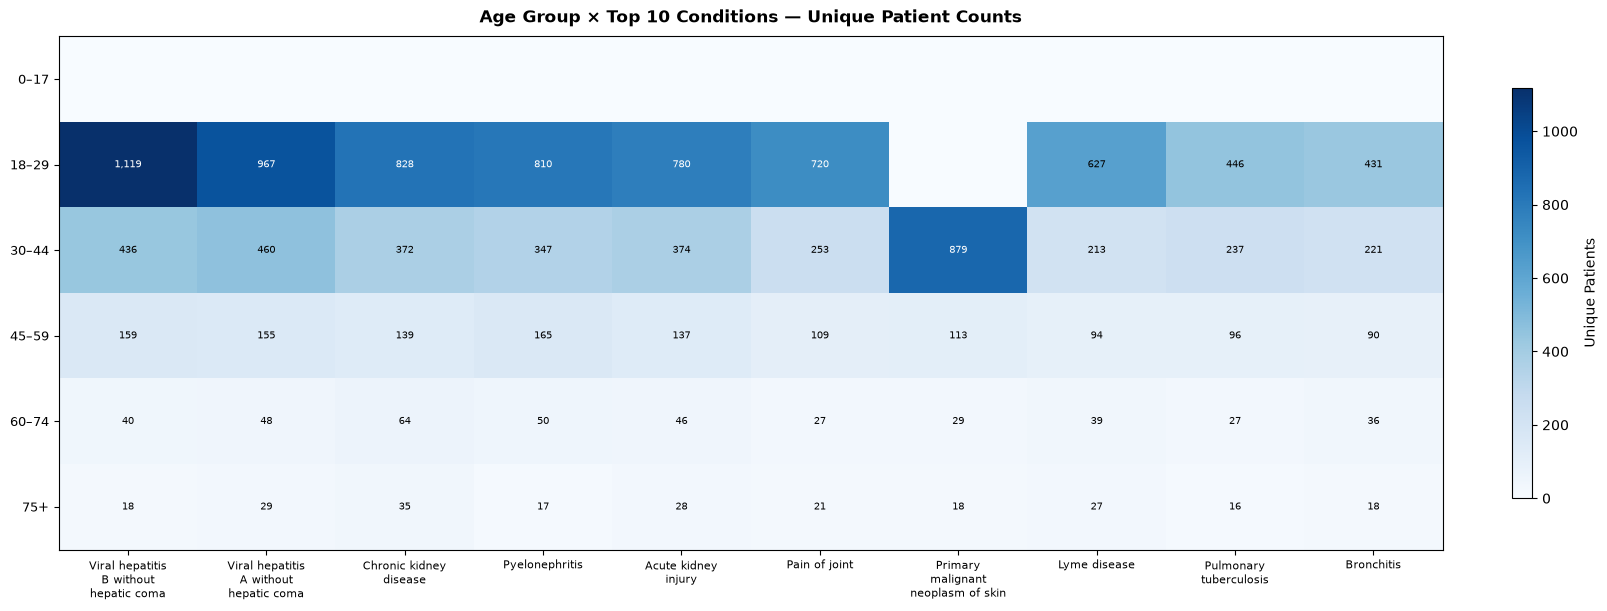

Age group × condition matrix (unique patient counts):
concept_name  Viral hepatitis B without...  Viral hepatitis A without...  Chronic kidney disease  Pyelonephritis  Acute kidney injury  Pain of joint  Primary malignant...  Lyme disease  Pulmonary tuberculosis  Bronchitis
age_group                                                                                                                                                                                                                   
0–17                                     0                             0                       0               0                    0              0                     0             0                       0           0
18–29                                 1119                           967                     828             810                  780            720                     0           627                     446         431
30–44                                  436                    

In [11]:
# Define ordered age-group labels
age_group_labels = [
    "0–17", "18–29", "30–44",
    "45–59", "60–74", "75+"
]

# Group patients into predefined age categories
conditions_per_patient["age_group"] = pd.cut(
    conditions_per_patient["age"],
    bins=[-np.inf, 17, 29, 44, 59, 74, np.inf],
    labels=age_group_labels
)

# Keep valid condition concepts for the analysis
valid_condition_records = co.loc[
    co["condition_concept_id"].notna()
    & co["condition_concept_id"].ne(0)
].copy()

# Add readable condition names and patient age groups
co_named_age = (
    valid_condition_records
    .merge(
        concept[["concept_id", "concept_name"]],
        left_on="condition_concept_id",
        right_on="concept_id",
        how="left"
    )
    .merge(
        conditions_per_patient[["person_id", "age_group"]],
        on="person_id",
        how="left"
    )
)

# Remove records without a mapped condition name or age group
co_named_age = co_named_age.dropna(
    subset=["concept_name", "age_group"]
)

# Identify the ten conditions affecting the most unique patients
top_conditions = (
    co_named_age
    .groupby("concept_name")["person_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .index
    .tolist()
)

# Count unique patients for each condition within each age group
heatmap_data = (
    co_named_age.loc[
        co_named_age["concept_name"].isin(top_conditions)
    ]
    .groupby(
        ["age_group", "concept_name"],
        observed=False
    )["person_id"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(
        index=age_group_labels,
        columns=top_conditions,
        fill_value=0
    )
)

# Create the patient-count heatmap
fig, ax = plt.subplots(
    figsize=(16, 6),
    constrained_layout=True
)

image = ax.imshow(
    heatmap_data.values,
    cmap="Blues",
    aspect="auto"
)

# Wrap long condition names for readability
condition_labels = [
    "\n".join(textwrap.wrap(name, width=16))
    for name in heatmap_data.columns
]

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(condition_labels, fontsize=8)

ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index, fontsize=9)

ax.set_title(
    "Age Group × Top 10 Conditions — Unique Patient Counts",
    fontweight="bold",
    pad=10
)

plt.colorbar(
    image,
    ax=ax,
    label="Unique Patients",
    shrink=0.8
)

# Add patient counts inside non-empty cells
maximum_count = heatmap_data.to_numpy().max()

for row_index in range(heatmap_data.shape[0]):
    for column_index in range(heatmap_data.shape[1]):
        patient_count = heatmap_data.iloc[
            row_index,
            column_index
        ]

        if patient_count > 0:
            text_colour = (
                "white"
                if patient_count > maximum_count * 0.6
                else "black"
            )

            ax.text(
                column_index,
                row_index,
                f"{patient_count:,}",
                ha="center",
                va="center",
                fontsize=7.5,
                color=text_colour
            )

plt.show()

# Shorten condition names for the printed matrix
short_names = {
    name: textwrap.shorten(
        name,
        width=28,
        placeholder="..."
    )
    for name in heatmap_data.columns
}

heatmap_display = heatmap_data.rename(
    columns=short_names
)

print("Age group × condition matrix (unique patient counts):")
print(heatmap_display.to_string())

## Analysing Medication Supply Duration

This cell examines the `days_supply` field in the drug exposure table. This field represents the estimated number of days for which a recorded medication supply should last.

The values are first converted to numeric format. Invalid, missing, zero, and negative values are excluded because they cannot represent a valid medication duration. The percentage of drug exposure records with usable days-supply information is then calculated to assess data completeness.

To prevent a small number of very large values from distorting the histogram, values above the 99th percentile are excluded from the plot and overall summary statistics. These records remain in the original dataset and are still included in the medication-level statistics.

Medication concept IDs are also linked to readable names. For the ten medications with the most valid days-supply records, the count, median duration, and mean duration are printed. The median is particularly useful because it is less affected by unusually large values than the mean.


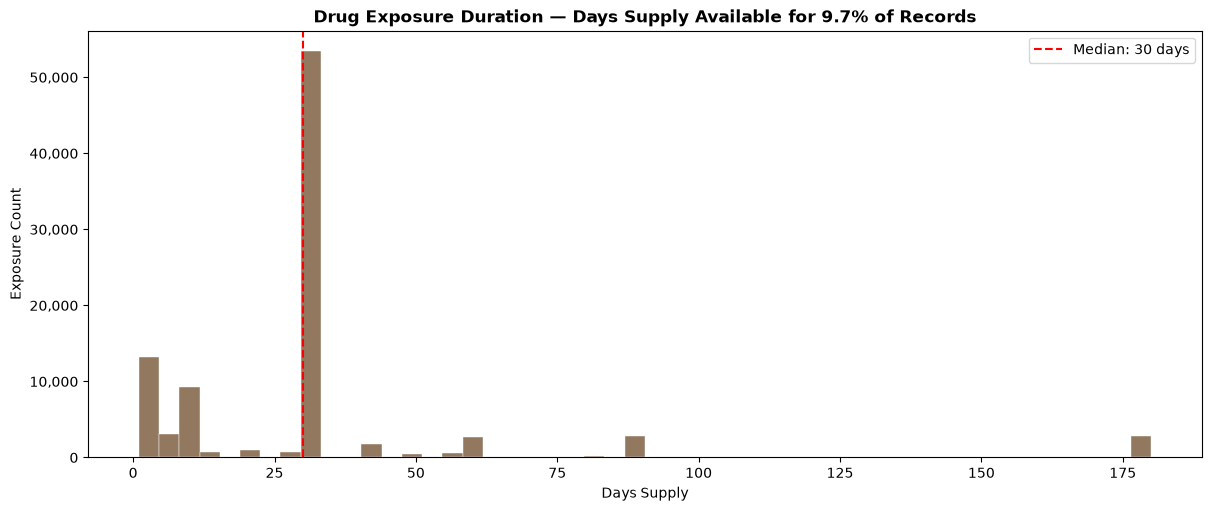

Days-supply coverage : 9.7% (93,439 / 962,858 exposures)
99th percentile cap  : 180 days
Median days supply   : 30 days
Mean days supply     : 31 days

Days supply by top medications where recorded:
Medication                                                 Count   Median     Mean
-----------------------------------------------------------------------------------
24 HR ciprofloxacin 500 MG Extended Release Oral...        3,502       10       10
ibuprofen                                                  3,268       30       30
prednisolone                                               2,304       90       89
prochlorperazine                                           2,146       30       30
metoprolol                                                 2,048       30       30
telbivudine                                                1,964       30       30
famotidine 40 MG Oral Tablet                               1,942       30       30
ferrous sulfate 325 MG Oral Tablet                   

In [12]:
# Create a separate copy to preserve the original drug exposure table
de_duration = de.copy()

# Convert days_supply values to numeric format
de_duration["days_supply_clean"] = pd.to_numeric(
    de_duration["days_supply"],
    errors="coerce"
)

# Keep records with valid and positive days-supply values
de_with_supply = de_duration.loc[
    de_duration["days_supply_clean"].notna()
    & de_duration["days_supply_clean"].gt(0)
].copy()

# Calculate the proportion of records with valid days supply
coverage_pct = (
    len(de_with_supply) / len(de_duration) * 100
    if len(de_duration) > 0
    else 0
)

if not de_with_supply.empty:
    # Calculate the 99th percentile for visualisation
    upper_limit = de_with_supply["days_supply_clean"].quantile(0.99)

    # Exclude values above the 99th percentile from the plot
    plot_values = de_with_supply.loc[
        de_with_supply["days_supply_clean"].le(upper_limit),
        "days_supply_clean"
    ]

    # Add readable medication names
    de_duration_named = de_with_supply.merge(
        concept[["concept_id", "concept_name"]],
        left_on="drug_concept_id",
        right_on="concept_id",
        how="left"
    )

    # Retain records without a matching medication name
    de_duration_named["concept_name"] = (
        de_duration_named["concept_name"]
        .fillna("Unmapped medication")
    )

    # Calculate duration statistics for the most recorded medications
    top_drug_stats = (
        de_duration_named
        .groupby("concept_name", as_index=False)
        .agg(
            record_count=("days_supply_clean", "count"),
            median_days=("days_supply_clean", "median"),
            mean_days=("days_supply_clean", "mean")
        )
        .sort_values("record_count", ascending=False)
        .head(10)
    )

    # Plot the days-supply distribution
    fig, ax = plt.subplots(
        figsize=(12, 5),
        constrained_layout=True
    )

    ax.hist(
        plot_values,
        bins=50,
        color=PALETTE[5],
        edgecolor="white",
        linewidth=0.3
    )

    ax.axvline(
        plot_values.median(),
        color="red",
        linestyle="--",
        label=f"Median: {plot_values.median():.0f} days"
    )

    ax.set_title(
        f"Drug Exposure Duration — Days Supply Available "
        f"for {coverage_pct:.1f}% of Records",
        fontweight="bold"
    )
    ax.set_xlabel("Days Supply")
    ax.set_ylabel("Exposure Count")
    ax.legend()

    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda value, _: f"{int(value):,}")
    )

    plt.show()

    # Print the overall duration summary
    print(
        f"Days-supply coverage : {coverage_pct:.1f}% "
        f"({len(de_with_supply):,} / {len(de_duration):,} exposures)"
    )
    print(f"99th percentile cap  : {upper_limit:.0f} days")
    print(f"Median days supply   : {plot_values.median():.0f} days")
    print(f"Mean days supply     : {plot_values.mean():.0f} days")

    # Print medication-level duration statistics
    print("\nDays supply by top medications where recorded:")
    print(
        f"{'Medication':<55} "
        f"{'Count':>8} "
        f"{'Median':>8} "
        f"{'Mean':>8}"
    )
    print("-" * 83)

    for row in top_drug_stats.itertuples(index=False):
        medication_name = textwrap.shorten(
            str(row.concept_name),
            width=53,
            placeholder="..."
        )

        print(
            f"{medication_name:<55} "
            f"{row.record_count:>8,} "
            f"{row.median_days:>8.0f} "
            f"{row.mean_days:>8.0f}"
        )

else:
    print("No valid positive days-supply values were found.")

## Exploring the Clinical Notes Corpus

This cell examines the structure and availability of the clinical notes before they are used for text analysis or model fine-tuning. A separate copy of the notes table is created so that the original data remain unchanged.

Two measures of note length are calculated: the number of characters and the number of words. Note-type concept IDs are also linked to readable labels using the OMOP concept table. Notes without a matching label are retained and marked as unmapped.

Three visualisations are produced. The first shows the distribution of note lengths in words, the second shows how many notes are available for each patient, and the third shows the number of notes recorded in each year. Median values are added to the first two plots to provide a summary that is less affected by unusually large values.

The printed output summarises the size of the notes corpus, the number of patients represented, typical note length, the maximum note length, and the most frequent note types. Patients without notes are not included in the notes-per-patient distribution, while notes with missing text or dates are excluded only from the relevant calculations.


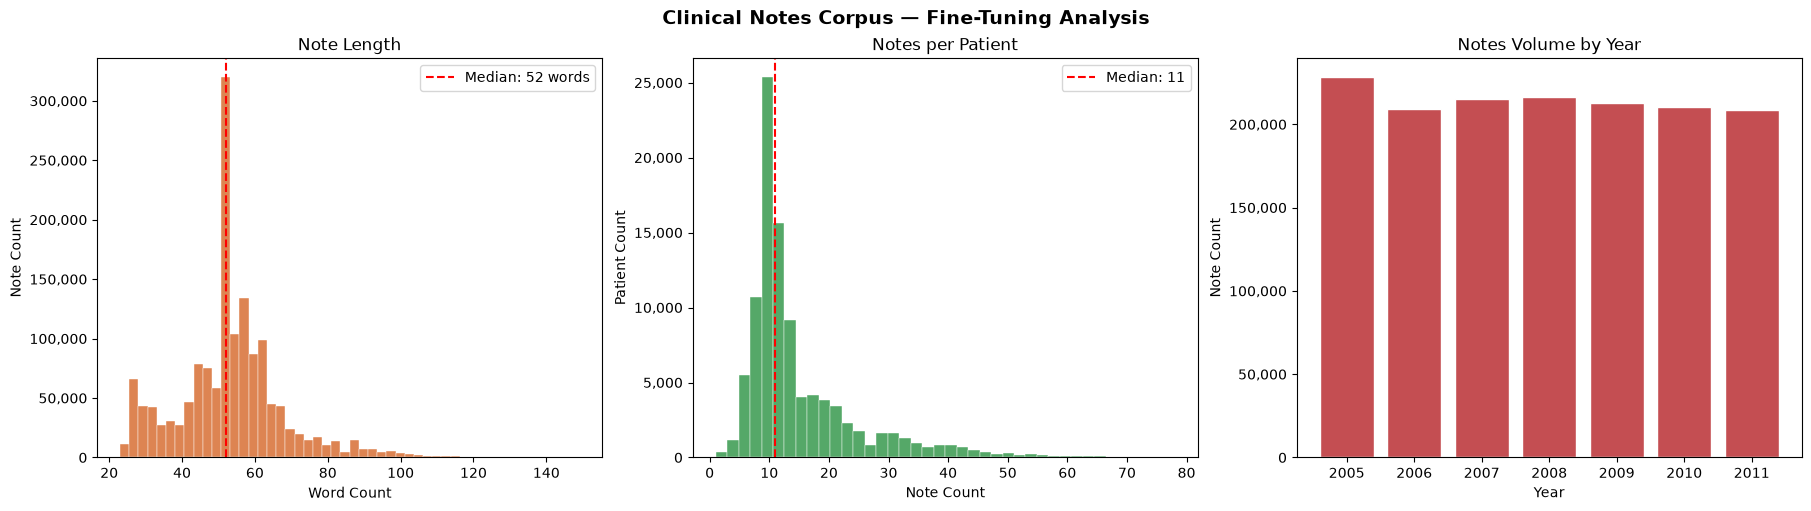

Notes Corpus Summary:
  Total notes          : 1,499,925
  Unique patients      : 99,414
  Average note length  : 378 characters / 53 words
  Median note length   : 377 characters / 52 words
  Maximum note length  : 1,090 characters
  Median notes/patient : 11.0

Top note types:
note_type
Emergency contraception declined    1499925


In [13]:
# Create a separate copy to preserve the original notes table
note_analysis = note.copy()

# Calculate note length in characters and words
note_analysis["note_length"] = (
    note_analysis["note_text"]
    .str.len()
)

note_analysis["word_count"] = (
    note_analysis["note_text"]
    .str.split()
    .str.len()
)

# Create a lookup table containing readable note-type labels
note_type_map = (
    concept[["concept_id", "concept_name"]]
    .rename(columns={
        "concept_id": "note_type_cid",
        "concept_name": "note_type"
    })
)

# Add readable note-type labels while retaining all note records
note_analysis = note_analysis.merge(
    note_type_map,
    left_on="note_type_concept_id",
    right_on="note_type_cid",
    how="left"
)

# Label records without a matching note type
note_analysis["note_type"] = (
    note_analysis["note_type"]
    .fillna("Unmapped note type")
)

# Count notes for each patient with at least one note
notes_per_patient = (
    note_analysis
    .groupby("person_id")
    .size()
)

# Extract the year from valid note dates
note_analysis["note_year"] = (
    note_analysis["note_date"]
    .dt.year
)

# Count notes recorded in each year
notes_by_year = (
    note_analysis
    .dropna(subset=["note_year"])
    .groupby("note_year")
    .size()
    .sort_index()
)

# Keep valid word counts for the note-length plot
word_counts = (
    note_analysis["word_count"]
    .dropna()
)

# Create three plots describing the notes corpus
fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 5),
    constrained_layout=True
)

fig.suptitle(
    "Clinical Notes Corpus — Fine-Tuning Analysis",
    fontsize=14,
    fontweight="bold"
)

# Plot the note-length distribution
axes[0].hist(
    word_counts,
    bins=50,
    color=PALETTE[1],
    edgecolor="white",
    linewidth=0.3
)

axes[0].axvline(
    word_counts.median(),
    color="red",
    linestyle="--",
    label=f"Median: {word_counts.median():,.0f} words"
)

axes[0].set_title("Note Length")
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Note Count")
axes[0].legend()

axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda value, _: f"{int(value):,}")
)

# Plot the number of notes per patient
axes[1].hist(
    notes_per_patient,
    bins=40,
    color=PALETTE[2],
    edgecolor="white",
    linewidth=0.3
)

axes[1].axvline(
    notes_per_patient.median(),
    color="red",
    linestyle="--",
    label=f"Median: {notes_per_patient.median():.0f}"
)

axes[1].set_title("Notes per Patient")
axes[1].set_xlabel("Note Count")
axes[1].set_ylabel("Patient Count")
axes[1].legend()

axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda value, _: f"{int(value):,}")
)

# Plot the annual volume of notes
axes[2].bar(
    notes_by_year.index.astype(int),
    notes_by_year.values,
    color=PALETTE[3],
    edgecolor="white"
)

axes[2].set_title("Notes Volume by Year")
axes[2].set_xlabel("Year")
axes[2].set_ylabel("Note Count")

axes[2].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda value, _: f"{int(value):,}")
)

plt.show()

# Print the main corpus statistics
print("Notes Corpus Summary:")
print(f"  Total notes          : {len(note_analysis):,}")
print(
    f"  Unique patients      : "
    f"{note_analysis['person_id'].nunique():,}"
)
print(
    f"  Average note length  : "
    f"{note_analysis['note_length'].mean():,.0f} characters / "
    f"{note_analysis['word_count'].mean():,.0f} words"
)
print(
    f"  Median note length   : "
    f"{note_analysis['note_length'].median():,.0f} characters / "
    f"{note_analysis['word_count'].median():,.0f} words"
)
print(
    f"  Maximum note length  : "
    f"{note_analysis['note_length'].max():,.0f} characters"
)
print(
    f"  Median notes/patient : "
    f"{notes_per_patient.median():.1f}"
)

# Display the ten most common note types
print("\nTop note types:")
print(
    note_analysis["note_type"]
    .value_counts()
    .head(10)
    .to_string()
)

## Previewing Sample Clinical Notes

This cell selects a small number of clinical notes for manual inspection. Only notes containing between 40 and 80 words are considered, which provides samples that are long enough to contain useful information but short enough to review easily.

Up to three notes are selected randomly. The fixed random seed ensures that the same samples are returned each time the notebook is run, improving reproducibility. For each sample, the note date, word count, and a shortened preview of the text are displayed.

This step provides an initial understanding of the writing style, structure, and content of the notes before they are used for clinical text classification. The selected notes are examples only and should not be treated as representative of the full corpus.


In [14]:
# Select notes that are suitable for manual inspection
eligible_notes = note_analysis.loc[
    note_analysis["word_count"].between(40, 80)
    & note_analysis["note_text"].notna()
].copy()

# Select up to three reproducible random samples
sample_size = min(3, len(eligible_notes))

samples = eligible_notes.sample(
    n=sample_size,
    random_state=99
)

print("=" * 70)
print(f"CLINICAL NOTES CORPUS — {sample_size} RANDOM SAMPLES")
print("Planned task: clinical text classification")
print("=" * 70)

# Display the date, word count, and text preview for each note
for sample_number, row in enumerate(
    samples.itertuples(index=False),
    start=1
):
    note_date = (
        row.note_date.date()
        if pd.notna(row.note_date)
        else "Missing date"
    )

    # Limit the displayed text to 600 characters
    note_preview = row.note_text[:600]

    print(f"\n--- Sample {sample_number} ---")
    print(
        f"Date: {note_date} | "
        f"Word count: {row.word_count:.0f}"
    )
    print(note_preview)
    print()

# Display overall corpus information
print("=" * 70)
print(
    f"Full corpus: {len(note_analysis):,} notes | "
    f"Median length: "
    f"{note_analysis['word_count'].median():.0f} words"
)
print("=" * 70)

CLINICAL NOTES CORPUS — 3 RANDOM SAMPLES
Planned task: clinical text classification

--- Sample 1 ---
Date: 2007-09-12 | Word count: 50
s:7 year old wfemale c/o the last 3 weeks h/o moderate seeing halos around lights,moderate reduced peripheral vision,severe pain and blurred vision in right eye. o:Height 53 in,Weight 91 lbs,Temperature 97.2 F,Pulse 90,SystolicBP 109,DiastolicBP 58,Respiration 18 Skin = needle marks on right elbow a:Glaucoma p:prescribe brimonidine 0.2% - 1 drp


--- Sample 2 ---
Date: 2010-02-23 | Word count: 54
s:23 year old female presents for follow-up on IUP.  She reports mild shortness of breath,mild bloating,severe heartburn. Patient does not smoke. Patient reports that she never drinks alcohol. o:Height 173 cm,Weight 85.8 kg,Temperature 37.8 C,Pulse 80,SystolicBP 120,DiastolicBP 81,Respiration 16 a:23 year old female G3P2 with IUP approximately 38 weeks pregnant p:Recheck in 1 week


--- Sample 3 ---
Date: 2008-07-25 | Word count: 51
s:15 year old female presen

## Identifying Measurements Outside Recorded Reference Ranges

This cell examines measurement records that contain a numeric result together with both lower and upper reference limits. Each result is classified as **Low**, **Normal**, or **High** by comparing `value_as_number` with its recorded reference range.

Readable measurement names are added using the OMOP `concept` table. For each measurement type, the code calculates the total number of results, the number below the lower limit, the number above the upper limit, and the percentage outside the reference range.

The ten measurement types with the highest abnormal percentages are displayed in a horizontal bar chart. An overall summary is also printed for all measurements with complete reference-range information.

Measurements without numeric results or complete reference ranges are excluded from this analysis but remain in the original dataset. A value outside its recorded range is an analytical flag and should not automatically be interpreted as a diagnosis, as reference ranges may vary by laboratory, unit, patient group, and clinical context.


In [15]:
# Keep measurements with numeric results and complete reference ranges
me_range = me.loc[
    me["value_as_number"].notna()
    & me["range_low"].notna()
    & me["range_high"].notna()
].copy()

# Remove records with invalid reference ranges
me_range = me_range.loc[
    me_range["range_low"] <= me_range["range_high"]
].copy()

if not me_range.empty:
    # Classify results using their recorded reference limits
    me_range["status"] = np.select(
        [
            me_range["value_as_number"] < me_range["range_low"],
            me_range["value_as_number"] > me_range["range_high"]
        ],
        ["Low", "High"],
        default="Normal"
    )

    # Add readable measurement names
    me_range_named = me_range.merge(
        concept[["concept_id", "concept_name"]],
        left_on="measurement_concept_id",
        right_on="concept_id",
        how="left"
    )

    # Retain measurements without a matching concept name
    me_range_named["concept_name"] = (
        me_range_named["concept_name"]
        .fillna("Unmapped measurement")
    )

    # Create indicators used in the grouped calculations
    me_range_named["is_low"] = me_range_named["status"].eq("Low")
    me_range_named["is_high"] = me_range_named["status"].eq("High")
    me_range_named["is_abnormal"] = me_range_named["status"].ne("Normal")

    # Summarise results for each measurement type
    measurement_abnormality = (
        me_range_named
        .groupby("concept_name", as_index=False)
        .agg(
            total=("measurement_id", "count"),
            n_low=("is_low", "sum"),
            n_high=("is_high", "sum"),
            abnormal_rate=("is_abnormal", "mean")
        )
    )

    # Convert the abnormal proportion to a percentage
    measurement_abnormality["pct_abnormal"] = (
        measurement_abnormality["abnormal_rate"] * 100
    )

    # Select the ten measurement types with the highest abnormal rate
    abnormal_summary = (
        measurement_abnormality
        .sort_values(
            ["pct_abnormal", "total"],
            ascending=[False, False]
        )
        .head(10)
        .copy()
    )

    # Plot abnormal percentages
    fig, ax = plt.subplots(
        figsize=(12, 5),
        constrained_layout=True
    )

    bars = ax.barh(
        abnormal_summary["concept_name"],
        abnormal_summary["pct_abnormal"],
        color=PALETTE[3],
        edgecolor="white"
    )

    ax.set_title(
        "Top 10 Measurements by Percentage of Values Outside Reference Range",
        fontweight="bold"
    )
    ax.set_xlabel("Values Outside Reference Range (%)")
    ax.invert_yaxis()
    ax.tick_params(axis="y", labelsize=8)

    # Add percentage labels to the bars
    for bar, percentage in zip(
        bars,
        abnormal_summary["pct_abnormal"]
    ):
        ax.text(
            percentage + 0.5,
            bar.get_y() + bar.get_height() / 2,
            f"{percentage:.1f}%",
            va="center",
            fontsize=8
        )

    ax.set_xlim(
        0,
        min(105, abnormal_summary["pct_abnormal"].max() + 10)
    )

    plt.show()

    # Calculate the overall abnormal-result rate
    total_with_range = len(me_range_named)
    abnormal_count = int(me_range_named["is_abnormal"].sum())
    abnormal_percentage = abnormal_count / total_with_range * 100

    print(f"Measurements with valid reference ranges : {total_with_range:,}")
    print(
        f"Values outside reference range           : "
        f"{abnormal_count:,} ({abnormal_percentage:.1f}%)"
    )

    print("\nTop 10 measurement types by abnormal rate:")
    print(
        abnormal_summary[
            ["concept_name", "total", "n_low", "n_high", "pct_abnormal"]
        ].to_string(index=False)
    )

else:
    print("No measurements have valid and complete reference ranges.")

No measurements have valid and complete reference ranges.


## Keyword-Based Analysis of Clinical Note Content

This cell performs an exploratory analysis of the topics discussed in the clinical notes. A set of keywords is defined for eight broad categories, including vaccination, preventive care, acute illness, chronic disease management, medication review, laboratory results, mental health, and injury.

A reproducible random sample of up to 50,000 notes is selected to reduce processing time. The note text is converted to lowercase so that matching is not affected by capitalisation. Each note is then checked for the presence of one or more keywords from each category.

The resulting counts are displayed in a horizontal bar chart and reported as percentages of the sampled notes. The code also calculates how many notes match at least one category and how many do not match any of the predefined keywords.

These categories are not mutually exclusive. A single note may be counted in several categories if it contains keywords from multiple groups. This method provides a simple overview of the corpus, but it does not fully capture clinical meaning, context, negation, or alternative terminology. It should therefore be treated as an exploratory step rather than a final clinical text-classification method.


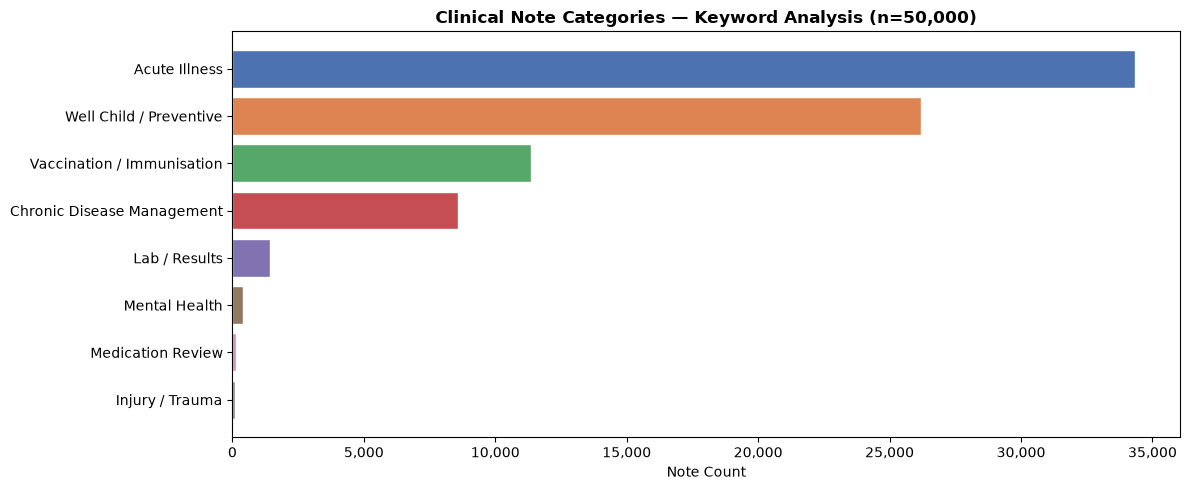

Content category distribution (50,000 notes):
  Acute Illness                       34,331 (68.7%)
  Well Child / Preventive             26,191 (52.4%)
  Vaccination / Immunisation          11,370 (22.7%)
  Chronic Disease Management           8,577 (17.2%)
  Lab / Results                        1,448 (2.9%)
  Mental Health                          405 (0.8%)
  Medication Review                      145 (0.3%)
  Injury / Trauma                        106 (0.2%)

Notes matching at least one category : 46,503 / 50,000 (93.0%)
Notes with no keyword match          : 3,497 (7.0%)


In [16]:
# Define keywords representing broad clinical note categories
keywords = {
    "Vaccination / Immunisation": [
        "vaccine", "vaccination", "immunis", "immuniz",
        "booster", "mmr", "flu shot"
    ],
    "Well Child / Preventive": [
        "well child", "well-child", "routine exam",
        "preventive", "health maintenance"
    ],
    "Acute Illness": [
        "fever", "infection", "acute", "presents with",
        "complains of", "sore throat", "cough"
    ],
    "Chronic Disease Management": [
        "chronic", "diabetes", "hypertension", "asthma",
        "follow-up", "follow up", "management"
    ],
    "Medication Review": [
        "medication", "prescription", "refill",
        "dosage", "drug", "pharmacy"
    ],
    "Lab / Results": [
        "laboratory", "result", "blood test",
        "cbc", "hba1c", "creatinine", "lipid"
    ],
    "Mental Health": [
        "anxiety", "depression", "mental health",
        "psychiatr", "counsel", "mood"
    ],
    "Injury / Trauma": [
        "injury", "trauma", "fracture",
        "wound", "fall", "laceration"
    ]
}

# Select a reproducible sample of up to 50,000 notes
sample_size = min(50_000, len(note_analysis))

note_sample = note_analysis.sample(
    n=sample_size,
    random_state=42
).copy()

# Prepare lowercase text for case-insensitive keyword matching
note_sample["note_lower"] = (
    note_sample["note_text"]
    .fillna("")
    .str.lower()
)

# Store a match indicator for each category
category_matches = pd.DataFrame(
    index=note_sample.index
)

for category, category_keywords in keywords.items():
    # Escape special characters before creating the regex pattern
    pattern = "|".join(
        re.escape(keyword.lower())
        for keyword in category_keywords
    )

    category_matches[category] = (
        note_sample["note_lower"]
        .str.contains(pattern, regex=True, na=False)
    )

# Count the number of matching notes in each category
category_counts = (
    category_matches
    .sum()
    .sort_values(ascending=False)
)

# Plot keyword-category frequencies
fig, ax = plt.subplots(figsize=(12, 5))

ax.barh(
    category_counts.index,
    category_counts.values,
    color=[
        PALETTE[index % len(PALETTE)]
        for index in range(len(category_counts))
    ],
    edgecolor="white"
)

ax.set_title(
    f"Clinical Note Categories — Keyword Analysis "
    f"(n={sample_size:,})",
    fontweight="bold"
)
ax.set_xlabel("Note Count")
ax.invert_yaxis()

ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda value, _: f"{int(value):,}")
)

plt.tight_layout()
plt.show()

# Identify notes matching at least one category
any_match = category_matches.any(axis=1)

# Print category counts and percentages
print(f"Content category distribution ({sample_size:,} notes):")

for category, count in category_counts.items():
    percentage = count / sample_size * 100 if sample_size else 0

    print(
        f"  {category:<35} "
        f"{count:>6,} ({percentage:.1f}%)"
    )

matched_count = int(any_match.sum())
unmatched_count = int((~any_match).sum())

print(
    f"\nNotes matching at least one category : "
    f"{matched_count:,} / {sample_size:,} "
    f"({any_match.mean() * 100:.1f}%)"
)
print(
    f"Notes with no keyword match          : "
    f"{unmatched_count:,} "
    f"({(~any_match).mean() * 100:.1f}%)"
)

# Check whether mapped note-type labels contain useful variation
if "note_type" in note_analysis.columns:
    mapped_note_types = (
        note_analysis.loc[
            note_analysis["note_type"].ne("Unmapped note type"),
            "note_type"
        ]
        .dropna()
        .unique()
    )